In [1]:
import torch
print(torch.cuda.is_available())  # 返回True表示可用


d:\anaconda\envs\dp-withgpu\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\anaconda\envs\dp-withgpu\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
d:\anaconda\envs\dp-withgpu\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


False


In [2]:
import sys 
sys.path.append("..")

import torch
import numpy as np
from sklearn.model_selection import train_test_split
from rdkit import Chem
from models.dataset import get_dataset
from models.training import Training
from models.trainer import Trainer
from torch_geometric.loader import DataLoader

In [3]:
train_folder_path_N, train_folder_path_P = r'..\data\N', r'..\data\P'
train_datas = get_dataset(train_folder_path_N,mode='N')+get_dataset(train_folder_path_P,mode='P')
test_datas = get_dataset(r'..\data\验证N',mode='N')+get_dataset( r'..\data\验证P',mode='P')

train, val = train_test_split(train_datas,test_size=0.1, shuffle=True, stratify=[float(i[-1]) for i in train_datas])
train_loader,val_loader = DataLoader(train,batch_size=16,shuffle=True), DataLoader(val,batch_size=16,shuffle=True)
test_loader = DataLoader(test_datas,batch_size=16,shuffle=False)

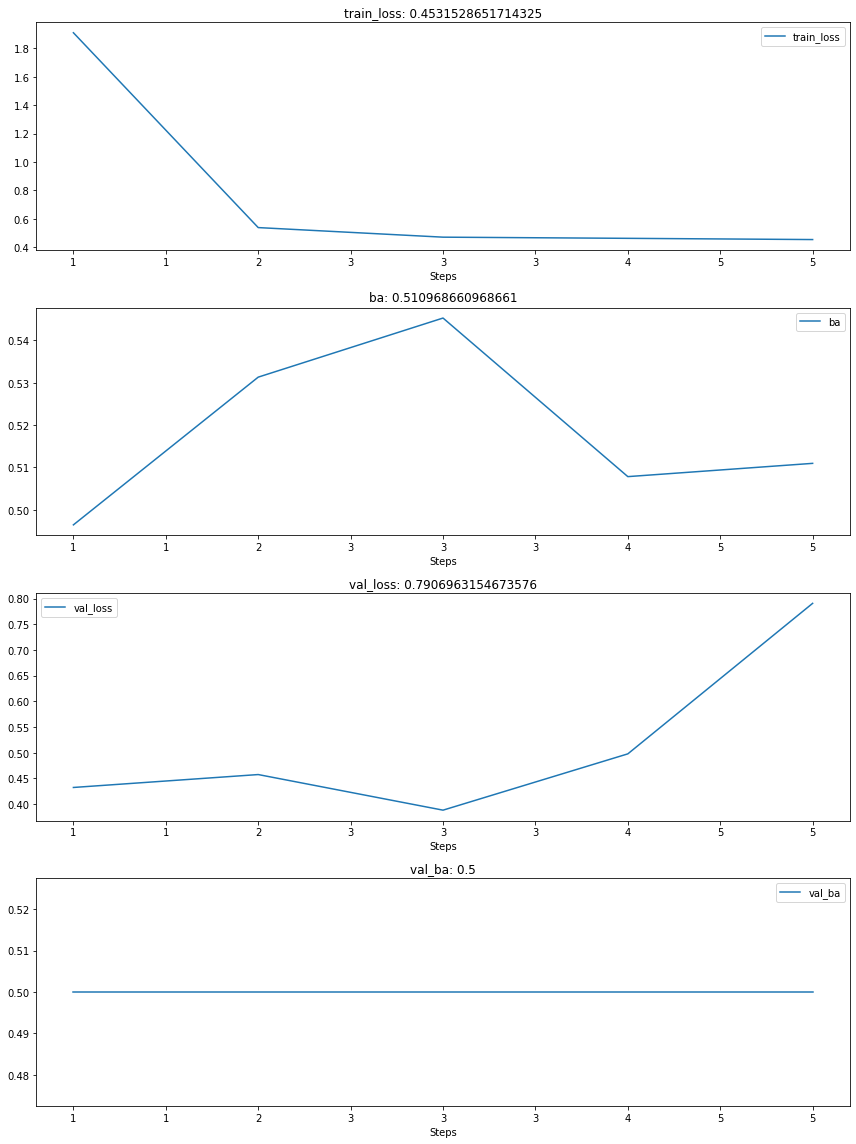

Epoch 6:  32%|███▏      | 9/28 [01:48<03:32, 11.20s/it, train_accuracy=0.75, train_loss=0.43]

In [ ]:
params = {
    "lstm_input_dim":100, 
    "lstm_hidden_dim":128,
    "lstm_layer_dim": 2, 
    "output_dim": 2, 
    "dropout": 0.2, 
    "lr": 0.0025, 
    "weight_decay": 7e-5, 
    "n_epochs": 1000
    }

TR = Training(train_loader,val_loader,params)
trainer,model,(train_losses, train_scores), (valid_losses, valid_scores),best_state_dict = TR.train()
torch.save(best_state_dict,"model_saved\lstm_params_split.pkl")

In [ ]:
train_datas[0]

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.subplot(1,2,1)
plt.plot(range(0,len(train_losses)),train_losses)
plt.subplot(1,2,2)
plt.plot(range(0,len(train_scores)),train_scores)
plt

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.subplot(1,2,1) 
plt.plot(range(0,len(valid_losses)),valid_losses)
plt.subplot(1,2,2)
plt.plot(range(0,len(valid_scores)),valid_scores)
plt

In [ ]:

model = None
trainer = Trainer(model, optimizer=  torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=7e-5), train_loader = None, valid_loader = None)
_,target , out = trainer.predict(test_loader) #降维成（1，5）的特征向量

out = out.reshape(-1,2)
out = torch.tensor(out)
_,output = torch.max(out,dim = 1)
print(output)

#
from sklearn.metrics import accuracy_score,f1_score,matthews_corrcoef,precision_score,balanced_accuracy_score,recall_score

output = np.array(output).flatten()
a = balanced_accuracy_score(target,output)
b = f1_score(target,output,average="weighted")
c = matthews_corrcoef(target,output)
d = precision_score(target,output,average="weighted")
e = recall_score(target,output,average="weighted")

print("ba={}".format(a))
print("f1={}".format(b))
print("mcc={}".format(c))
print("pre={}".format(d))
print("recall={}".format(e))
print(accuracy_score(target,output))

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
c = confusion_matrix(target,output)
sns.heatmap(c,annot=True,cmap="YlGnBu")

plt.xlabel('predict') #x轴
plt.ylabel('true') #y轴